Dataset loaded successfully.
Earliest Date: 2011-01-04
Latest Date: 2014-12-31
Total Transactions: 9994
Total Customers: 793

TUNING BACKTEST
Customers: 785
Actual Churn Rate: 64.08 %

MILESTONE 2 - TUNING BASELINE
--------------------------------
Accuracy: 0.4675
Precision: 0.6341
Recall: 0.3996
F1 Score: 0.4902
False Positives: 116
False Positive Rate: 41.13 %

Total candidate rules tested: 1650
Candidates reducing FP while preserving recall: 198

SELECTED MILESTONE 3 RULE
Rule Type: Recency + 2 Behaviour Signals
Recency Threshold: 135.0
Frequency Threshold: 12.0
Spending Threshold: 2747.86
Average Order Value Threshold: 287.81

TUNING PERFORMANCE
Accuracy: 0.4803
Precision: 0.6462
Recall: 0.4175
F1 Score: 0.5072
False Positives: 115

FINAL UNSEEN BACKTEST

MILESTONE 2 CONFUSION MATRIX
[[199 137]
 [233 218]]

MILESTONE 3 CONFUSION MATRIX
[[215 121]
 [252 199]]

MILESTONE 2 VS MILESTONE 3

             Metric  Milestone 2  Milestone 3
           Accuracy     0.529860     0.526048
    

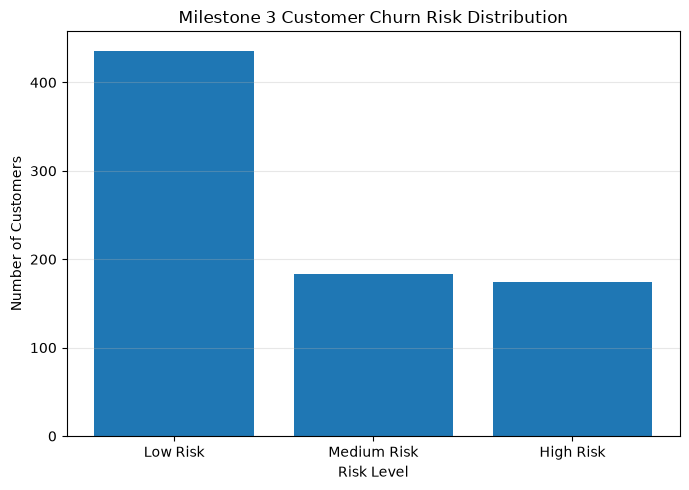


Day 6 completed successfully.

Files Created:
1. customer_churn_milestone3.csv
2. milestone2_vs_milestone3_metrics.csv
3. churn_candidate_rules.csv


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# Load Dataset

df = pd.read_csv("../../week1/preprocessing/cleaned_dataset.csv")

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d-%m-%Y"
)

print("Dataset loaded successfully.")
print("Earliest Date:", df["Order Date"].min().date())
print("Latest Date:", df["Order Date"].max().date())
print("Total Transactions:", len(df))
print("Total Customers:", df["Customer ID"].nunique())


# Customer Feature Creation

def create_customer_features(data, cutoff_date):

    customer_df = data.groupby("Customer ID").agg(
        LastPurchaseDate=("Order Date", "max"),
        PurchaseFrequency=("Order ID", "count"),
        TotalSpending=("Total amount", "sum"),
        AverageOrderValue=("Total amount", "mean")
    ).reset_index()

    customer_df["DaysSinceLastPurchase"] = (
        cutoff_date - customer_df["LastPurchaseDate"]
    ).dt.days

    return customer_df


# Historical Backtest

def create_backtest(cutoff_date, observation_days=90):

    cutoff_date = pd.Timestamp(cutoff_date)
    observation_end = cutoff_date + pd.Timedelta(days=observation_days)

    past_data = df[
        df["Order Date"] < cutoff_date
    ].copy()

    future_data = df[
        (df["Order Date"] >= cutoff_date)
        &
        (df["Order Date"] < observation_end)
    ].copy()

    customer_df = create_customer_features(
        past_data,
        cutoff_date
    )

    future_active_customers = set(
        future_data["Customer ID"].unique()
    )

    customer_df["ActualChurn"] = (
        customer_df["Customer ID"].apply(
            lambda customer_id:
            0 if customer_id in future_active_customers else 1
        )
    )

    return customer_df


# Milestone 2 Baseline

def milestone2_prediction(row):

    if row["DaysSinceLastPurchase"] > 180:
        return 1

    return 0


# Evaluation

def evaluate(y_true, y_pred):

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    if (fp + tn) > 0:
        fpr = fp / (fp + tn)
    else:
        fpr = 0

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "FPR": fpr
    }


# Tuning Backtest

TUNING_CUTOFF = "2014-04-01"

tuning_df = create_backtest(
    TUNING_CUTOFF,
    observation_days=90
)

print("\n========================================")
print("TUNING BACKTEST")
print("========================================")

print("Customers:", len(tuning_df))

print(
    "Actual Churn Rate:",
    round(tuning_df["ActualChurn"].mean() * 100, 2),
    "%"
)


# Milestone 2 Tuning Performance

tuning_df["M2Prediction"] = tuning_df.apply(
    milestone2_prediction,
    axis=1
)

m2_tuning = evaluate(
    tuning_df["ActualChurn"],
    tuning_df["M2Prediction"]
)

print("\nMILESTONE 2 - TUNING BASELINE")
print("--------------------------------")

print("Accuracy:", round(m2_tuning["Accuracy"], 4))
print("Precision:", round(m2_tuning["Precision"], 4))
print("Recall:", round(m2_tuning["Recall"], 4))
print("F1 Score:", round(m2_tuning["F1"], 4))
print("False Positives:", m2_tuning["FP"])

print(
    "False Positive Rate:",
    round(m2_tuning["FPR"] * 100, 2),
    "%"
)


# Candidate Thresholds

recency_thresholds = [
    90, 105, 120, 135, 150,
    165, 180, 195, 210, 225, 240
]

frequency_quantiles = [
    tuning_df["PurchaseFrequency"].quantile(0.25),
    tuning_df["PurchaseFrequency"].quantile(0.40),
    tuning_df["PurchaseFrequency"].quantile(0.50),
    tuning_df["PurchaseFrequency"].quantile(0.60),
    tuning_df["PurchaseFrequency"].quantile(0.75)
]

spending_quantiles = [
    tuning_df["TotalSpending"].quantile(0.25),
    tuning_df["TotalSpending"].quantile(0.40),
    tuning_df["TotalSpending"].quantile(0.50),
    tuning_df["TotalSpending"].quantile(0.60),
    tuning_df["TotalSpending"].quantile(0.75)
]

aov_quantiles = [
    tuning_df["AverageOrderValue"].quantile(0.25),
    tuning_df["AverageOrderValue"].quantile(0.50),
    tuning_df["AverageOrderValue"].quantile(0.75)
]

frequency_quantiles = sorted(set(frequency_quantiles))
spending_quantiles = sorted(set(spending_quantiles))
aov_quantiles = sorted(set(aov_quantiles))


# Candidate Rule Evaluation

results = []

for recency_limit in recency_thresholds:

    for frequency_limit in frequency_quantiles:

        for spending_limit in spending_quantiles:

            for aov_limit in aov_quantiles:

                predictions_a = []

                for _, row in tuning_df.iterrows():

                    long_inactivity = (
                        row["DaysSinceLastPurchase"] > recency_limit
                    )

                    weak_frequency = (
                        row["PurchaseFrequency"] <= frequency_limit
                    )

                    if long_inactivity and weak_frequency:
                        prediction = 1
                    else:
                        prediction = 0

                    predictions_a.append(prediction)

                metrics_a = evaluate(
                    tuning_df["ActualChurn"],
                    predictions_a
                )

                results.append({
                    "Rule": "Recency + Frequency",
                    "RecencyThreshold": recency_limit,
                    "FrequencyThreshold": frequency_limit,
                    "SpendingThreshold": spending_limit,
                    "AOVThreshold": aov_limit,
                    "Accuracy": metrics_a["Accuracy"],
                    "Precision": metrics_a["Precision"],
                    "Recall": metrics_a["Recall"],
                    "F1": metrics_a["F1"],
                    "FP": metrics_a["FP"],
                    "FN": metrics_a["FN"],
                    "TP": metrics_a["TP"],
                    "TN": metrics_a["TN"],
                    "FPR": metrics_a["FPR"]
                })

                predictions_b = []

                for _, row in tuning_df.iterrows():

                    long_inactivity = (
                        row["DaysSinceLastPurchase"] > recency_limit
                    )

                    weak_frequency = (
                        row["PurchaseFrequency"] <= frequency_limit
                    )

                    weak_spending = (
                        row["TotalSpending"] <= spending_limit
                    )

                    weak_aov = (
                        row["AverageOrderValue"] <= aov_limit
                    )

                    weak_behaviour_count = sum([
                        weak_frequency,
                        weak_spending,
                        weak_aov
                    ])

                    if (
                        long_inactivity
                        and weak_behaviour_count >= 2
                    ):
                        prediction = 1
                    else:
                        prediction = 0

                    predictions_b.append(prediction)

                metrics_b = evaluate(
                    tuning_df["ActualChurn"],
                    predictions_b
                )

                results.append({
                    "Rule": "Recency + 2 Behaviour Signals",
                    "RecencyThreshold": recency_limit,
                    "FrequencyThreshold": frequency_limit,
                    "SpendingThreshold": spending_limit,
                    "AOVThreshold": aov_limit,
                    "Accuracy": metrics_b["Accuracy"],
                    "Precision": metrics_b["Precision"],
                    "Recall": metrics_b["Recall"],
                    "F1": metrics_b["F1"],
                    "FP": metrics_b["FP"],
                    "FN": metrics_b["FN"],
                    "TP": metrics_b["TP"],
                    "TN": metrics_b["TN"],
                    "FPR": metrics_b["FPR"]
                })


# Select Best Candidate

results_df = pd.DataFrame(results)

print(
    "\nTotal candidate rules tested:",
    len(results_df)
)

minimum_recall = max(
    0,
    m2_tuning["Recall"] - 0.05
)

acceptable_candidates = results_df[
    (results_df["FP"] < m2_tuning["FP"])
    &
    (results_df["Recall"] >= minimum_recall)
].copy()

print(
    "Candidates reducing FP while preserving recall:",
    len(acceptable_candidates)
)

if acceptable_candidates.empty:

    acceptable_candidates = results_df[
        results_df["FP"] < m2_tuning["FP"]
    ].copy()

if acceptable_candidates.empty:

    raise ValueError(
        "No tested Milestone 3 rule reduced false positives."
    )

acceptable_candidates = acceptable_candidates.sort_values(
    by=[
        "F1",
        "Accuracy",
        "Recall",
        "FP"
    ],
    ascending=[
        False,
        False,
        False,
        True
    ]
)

best_rule = acceptable_candidates.iloc[0]

BEST_RULE = best_rule["Rule"]
BEST_RECENCY = float(best_rule["RecencyThreshold"])
BEST_FREQUENCY = float(best_rule["FrequencyThreshold"])
BEST_SPENDING = float(best_rule["SpendingThreshold"])
BEST_AOV = float(best_rule["AOVThreshold"])


# Selected Rule

print("\n========================================")
print("SELECTED MILESTONE 3 RULE")
print("========================================")

print("Rule Type:", BEST_RULE)
print("Recency Threshold:", BEST_RECENCY)
print("Frequency Threshold:", round(BEST_FREQUENCY, 2))
print("Spending Threshold:", round(BEST_SPENDING, 2))
print("Average Order Value Threshold:", round(BEST_AOV, 2))

print("\nTUNING PERFORMANCE")

print("Accuracy:", round(best_rule["Accuracy"], 4))
print("Precision:", round(best_rule["Precision"], 4))
print("Recall:", round(best_rule["Recall"], 4))
print("F1 Score:", round(best_rule["F1"], 4))
print("False Positives:", int(best_rule["FP"]))


# Milestone 3 Prediction

def milestone3_prediction(row):

    long_inactivity = (
        row["DaysSinceLastPurchase"] > BEST_RECENCY
    )

    weak_frequency = (
        row["PurchaseFrequency"] <= BEST_FREQUENCY
    )

    weak_spending = (
        row["TotalSpending"] <= BEST_SPENDING
    )

    weak_aov = (
        row["AverageOrderValue"] <= BEST_AOV
    )

    if BEST_RULE == "Recency + Frequency":

        if long_inactivity and weak_frequency:
            return 1

        return 0

    weak_behaviour_count = sum([
        weak_frequency,
        weak_spending,
        weak_aov
    ])

    if (
        long_inactivity
        and weak_behaviour_count >= 2
    ):
        return 1

    return 0


# Final Backtest

FINAL_CUTOFF = "2014-07-01"

final_df = create_backtest(
    FINAL_CUTOFF,
    observation_days=90
)

final_df["Milestone2Prediction"] = final_df.apply(
    milestone2_prediction,
    axis=1
)

final_df["Milestone3Prediction"] = final_df.apply(
    milestone3_prediction,
    axis=1
)

m2_final = evaluate(
    final_df["ActualChurn"],
    final_df["Milestone2Prediction"]
)

m3_final = evaluate(
    final_df["ActualChurn"],
    final_df["Milestone3Prediction"]
)


# Confusion Matrices

print("\n========================================")
print("FINAL UNSEEN BACKTEST")
print("========================================")

print("\nMILESTONE 2 CONFUSION MATRIX")

print(
    confusion_matrix(
        final_df["ActualChurn"],
        final_df["Milestone2Prediction"],
        labels=[0, 1]
    )
)

print("\nMILESTONE 3 CONFUSION MATRIX")

print(
    confusion_matrix(
        final_df["ActualChurn"],
        final_df["Milestone3Prediction"],
        labels=[0, 1]
    )
)


# Performance Comparison

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "False Positives",
        "False Positive Rate",
        "False Negatives",
        "True Positives"
    ],

    "Milestone 2": [
        m2_final["Accuracy"],
        m2_final["Precision"],
        m2_final["Recall"],
        m2_final["F1"],
        m2_final["FP"],
        m2_final["FPR"],
        m2_final["FN"],
        m2_final["TP"]
    ],

    "Milestone 3": [
        m3_final["Accuracy"],
        m3_final["Precision"],
        m3_final["Recall"],
        m3_final["F1"],
        m3_final["FP"],
        m3_final["FPR"],
        m3_final["FN"],
        m3_final["TP"]
    ]
})

print("\n========================================")
print("MILESTONE 2 VS MILESTONE 3")
print("========================================\n")

print(
    comparison.to_string(index=False)
)


# False Positive Evaluation

print("\n========================================")
print("FALSE POSITIVE EVALUATION")
print("========================================")

if m3_final["FP"] < m2_final["FP"]:

    reduction = (
        m2_final["FP"] - m3_final["FP"]
    )

    percentage_reduction = (
        reduction / m2_final["FP"] * 100
    )

    print("SUCCESS: False positives reduced.")

    print(
        "Milestone 2 False Positives:",
        m2_final["FP"]
    )

    print(
        "Milestone 3 False Positives:",
        m3_final["FP"]
    )

    print("Reduction:", reduction)

    print(
        "Percentage Reduction:",
        round(percentage_reduction, 2),
        "%"
    )

else:

    print(
        "Milestone 3 did not reduce false positives."
    )


# Overall Performance

print("\n========================================")
print("OVERALL PERFORMANCE CHECK")
print("========================================")

if m3_final["Accuracy"] >= m2_final["Accuracy"]:
    print("Accuracy maintained/improved.")
else:
    print("Accuracy decreased.")

if m3_final["Precision"] >= m2_final["Precision"]:
    print("Precision maintained/improved.")
else:
    print("Precision decreased.")

if m3_final["Recall"] >= m2_final["Recall"]:
    print("Recall maintained/improved.")
else:
    print("Recall decreased.")

if m3_final["F1"] >= m2_final["F1"]:
    print("F1 Score maintained/improved.")
else:
    print("F1 Score decreased.")


# Final Customer Risk

latest_date = df["Order Date"].max()

customer_df = create_customer_features(
    df,
    latest_date
)


def assign_final_risk(row):

    if milestone3_prediction(row) == 1:
        return "High Risk"

    elif row["DaysSinceLastPurchase"] > 90:
        return "Medium Risk"

    return "Low Risk"


customer_df["Risk"] = customer_df.apply(
    assign_final_risk,
    axis=1
)


# Risk Distribution

risk_order = [
    "Low Risk",
    "Medium Risk",
    "High Risk"
]

risk_counts = (
    customer_df["Risk"]
    .value_counts()
    .reindex(
        risk_order,
        fill_value=0
    )
)

print("\n========================================")
print("FINAL CUSTOMER RISK DISTRIBUTION")
print("========================================\n")

print(risk_counts)


# Visualization

plt.figure(figsize=(7, 5))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.title(
    "Milestone 3 Customer Churn Risk Distribution"
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# Save Results

customer_df.to_csv(
    "customer_churn_milestone3.csv",
    index=False
)

comparison.to_csv(
    "milestone2_vs_milestone3_metrics.csv",
    index=False
)

results_df.to_csv(
    "churn_candidate_rules.csv",
    index=False
)

print("\nDay 6 completed successfully.")

print("\nFiles Created:")
print("1. customer_churn_milestone3.csv")
print("2. milestone2_vs_milestone3_metrics.csv")
print("3. churn_candidate_rules.csv")